# OneCycle Learning Rate Scheduler with Keras

In this notebook, we demonstrate how to implement a **custom learning rate scheduler** using the OneCycle policy in Keras. We train a simple CNN on Fashion-MNIST and dynamically adjust the learning rate using a custom callback.

**Key Concepts:**
- OneCycleLR policy for dynamic LR scheduling
- Custom Keras callback
- LR visualization

# Load and normalize Dataset

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load and normalize Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# Define CNN model

In [25]:
# Define CNN model
def build_model():
    model = keras.models.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Training setup

In [26]:
# Training setupr using .assign
class OneCycleScheduler(keras.callbacks.Callback):
    def __init__(self, max_lr, steps, start_lr=None, last_lr=None):
        super().__init__()
        self.max_lr = max_lr
        self.start_lr = start_lr if start_lr else max_lr / 10
        self.last_lr = last_lr if last_lr else self.start_lr / 1000
        self.half = steps // 2
        self.steps = steps
        self.history = []

    def on_train_begin(self, logs=None):
        self.iter = 0

    def on_batch_begin(self, batch, logs=None):
        if self.iter < self.half:
            lr = self.start_lr + (self.max_lr - self.start_lr) * self.iter / self.half
        else:
            lr = self.max_lr - (self.max_lr - self.last_lr) * (self.iter - self.half) / (self.steps - self.half)
        self.model.optimizer.learning_rate.assign(lr)
        self.history.append(lr)
        self.iter += 1

# Training setup

In [27]:
# Training setup
batch_size = 64
epochs = 5
steps_per_epoch = len(X_train) // batch_size
total_steps = steps_per_epoch * epochs

# Compile and train model

In [28]:
# Compile and train model
model = build_model()
model.compile(optimizer=keras.optimizers.Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

one_cycle = OneCycleScheduler(max_lr=0.01, steps=total_steps)

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[one_cycle],
    verbose=2
)

Epoch 1/5
938/938 - 52s - 55ms/step - accuracy: 0.8267 - loss: 0.4792 - val_accuracy: 0.8631 - val_loss: 0.3714
Epoch 2/5
938/938 - 79s - 84ms/step - accuracy: 0.8763 - loss: 0.3328 - val_accuracy: 0.8776 - val_loss: 0.3571
Epoch 3/5
938/938 - 82s - 87ms/step - accuracy: 0.8823 - loss: 0.3194 - val_accuracy: 0.8777 - val_loss: 0.3277
Epoch 4/5
938/938 - 48s - 51ms/step - accuracy: 0.9039 - loss: 0.2530 - val_accuracy: 0.8992 - val_loss: 0.2808
Epoch 5/5
938/938 - 48s - 51ms/step - accuracy: 0.9324 - loss: 0.1771 - val_accuracy: 0.9108 - val_loss: 0.2589


# Plot OneCycle LR schedule

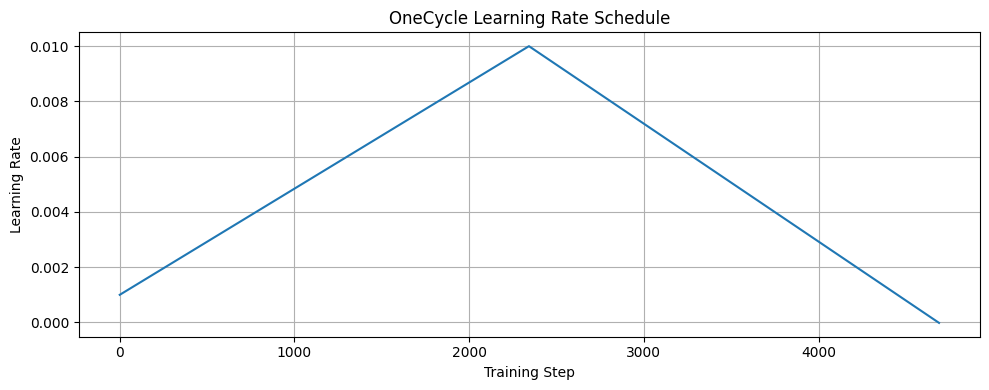

In [29]:
# Plot OneCycle LR schedule
plt.figure(figsize=(10, 4))
if one_cycle.history:
    plt.plot(one_cycle.history)
    plt.title("OneCycle Learning Rate Schedule")
    plt.xlabel("Training Step")
    plt.ylabel("Learning Rate")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Learning rate history is empty. Callback may not have run.")